# Tech Challenge — Análise Exploratória de Dados #

Este projeto tem como objetivo realizar uma análise exploratória do dataset de e-commerce da Olist, identificando padrões de comportamento de clientes, vendas, pagamentos e entregas.

A análise busca responder perguntas relevantes para o negócio, como:

- Evolução do volume de pedidos ao longo do tempo
- Métodos de pagamento mais utilizados
- Distribuição geográfica de clientes
- Avaliação dos pedidos pelos clientes
- Possíveis problemas no processo de entrega

A partir dessas análises será possível gerar insights que podem auxiliar na tomada de decisão e na melhoria da experiência do cliente. 

# Importação das bibliotecas #

Nesta etapa são importadas as bibliotecas utilizadas para manipulação de dados e visualização gráfica.

- **Pandas** → manipulação de dados
- **NumPy** → operações numéricas
- **Matplotlib** → criação de gráficos
- **Seaborn** → visualizações estatísticas

In [27]:
#instalação da biblioteca#

!pip install pandas numpy matplotlib seaborn plotly

Defaulting to user installation because normal site-packages is not writeable


In [44]:
#importação da biblioteca#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos datasets #

Nesta etapa os diferentes datasets disponibilizados são carregados para análise.

Os dados incluem informações sobre:

- Clientes
- Pedidos
- Itens dos pedidos
- Produtos
- Vendedores
- Pagamentos
- Avaliações dos pedidos

In [45]:
#carregar os datasets#

customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

# Visualização inicial dos dados #

Para entender a estrutura do dataset, são visualizadas as primeiras linhas de cada tabela.
Isso permite identificar as colunas disponíveis e compreender melhor o formato das informações.

In [46]:
#ver os dados#

orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# Estrutura e tipos de dados #

A função `info()` permite analisar a estrutura do dataset, identificando:

- tipos de dados
- quantidade de registros
- presença de valores nulos

In [47]:
#entendendo o dataset#

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


# Estatísticas descritivas #

Nesta etapa são analisadas estatísticas básicas das variáveis numéricas do dataset, como:

- média
- desvio padrão
- valores mínimos e máximos

Essa análise ajuda a entender a distribuição dos dados e identificar possíveis anomalias.

In [48]:
    #estatísticas#

orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


# Evolução do volume de pedidos ao longo do tempo #

Nesta análise buscamos entender como o número de pedidos evoluiu ao longo do tempo.

Esse tipo de visualização ajuda a identificar:

- crescimento da plataforma
- sazonalidade de vendas
- períodos de maior atividade

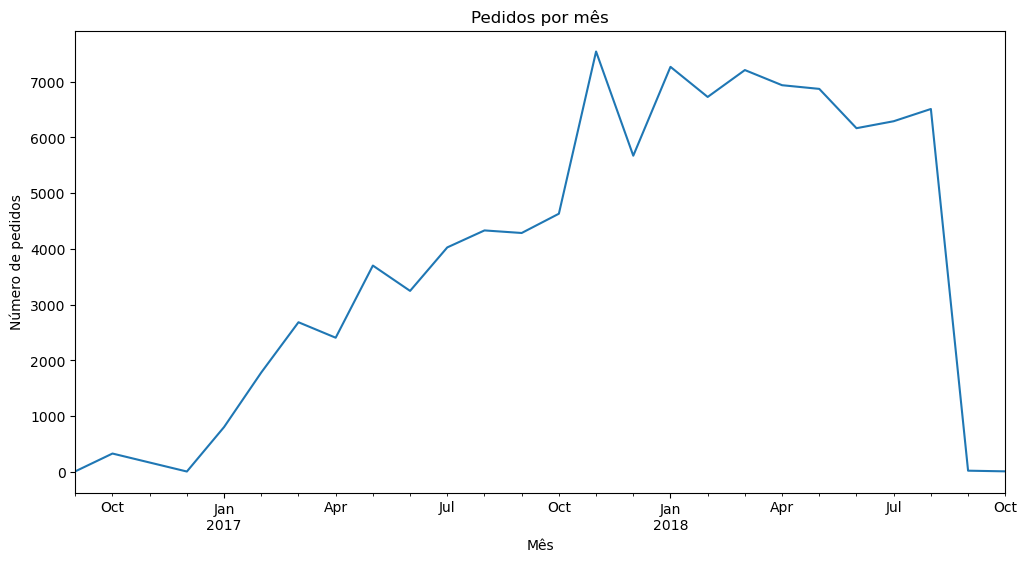

In [49]:
# converter para data
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# criar coluna de mês
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# contar pedidos por mês
orders_per_month = orders.groupby('order_month').size()

# gráfico
orders_per_month.plot(figsize=(12,6))

plt.title('Pedidos por mês')
plt.xlabel('Mês')
plt.ylabel('Número de pedidos')

plt.show()

# Métodos de pagamento mais utilizados #

A análise dos métodos de pagamento permite entender as preferências dos clientes na hora de finalizar suas compras.

Essa informação é importante para:

- otimização do checkout
- parcerias com meios de pagamento
- estratégias de conversão

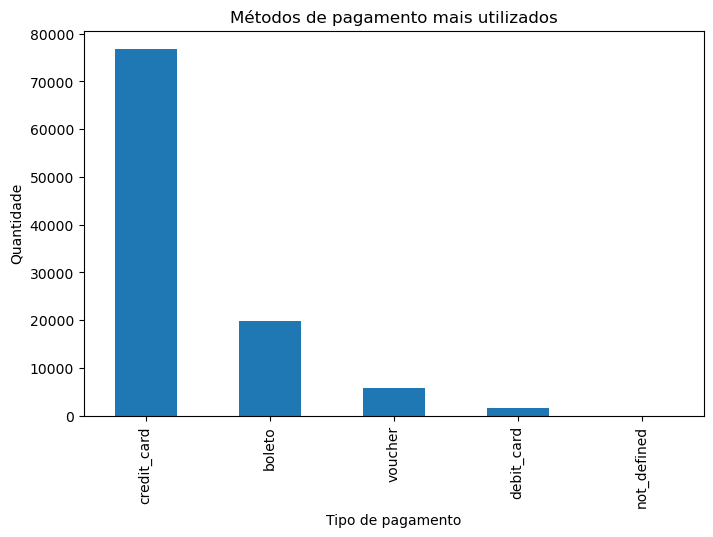

In [50]:
payment_counts = payments['payment_type'].value_counts()

payment_counts.plot(kind='bar', figsize=(8,5))

plt.title('Métodos de pagamento mais utilizados')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Quantidade')

plt.show()

# Avaliações dos pedidos #

Os clientes podem avaliar suas experiências após a compra.

Nesta análise observamos a distribuição das notas de avaliação para entender o nível geral de satisfação dos consumidores.

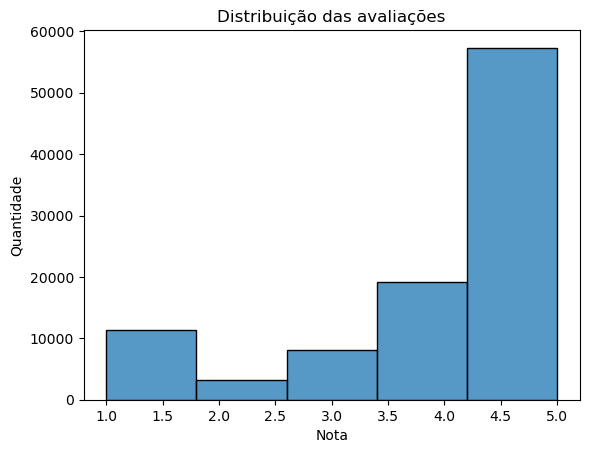

In [51]:
sns.histplot(reviews['review_score'], bins=5)

plt.title('Distribuição das avaliações')
plt.xlabel('Nota')
plt.ylabel('Quantidade')

plt.show()

# Análise de atraso nas entregas #

Uma das análises mais importantes para e-commerces é avaliar a eficiência logística.

Nesta etapa será analisada a diferença entre:

- data estimada de entrega
- data real de entrega

Isso permite identificar possíveis atrasos e avaliar a performance do processo logístico.

In [52]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

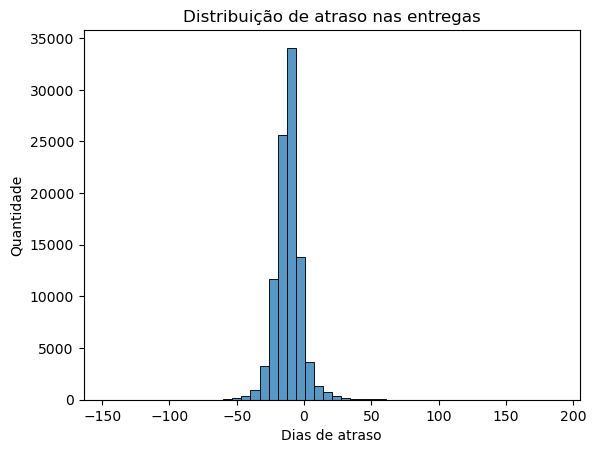

In [53]:
sns.histplot(orders['delivery_delay'].dropna(), bins=50)

plt.title('Distribuição de atraso nas entregas')
plt.xlabel('Dias de atraso')
plt.ylabel('Quantidade')

plt.show()

# Relação entre atraso na entrega e avaliação #

Aqui analisamos se atrasos nas entregas impactam na avaliação feita pelos clientes.

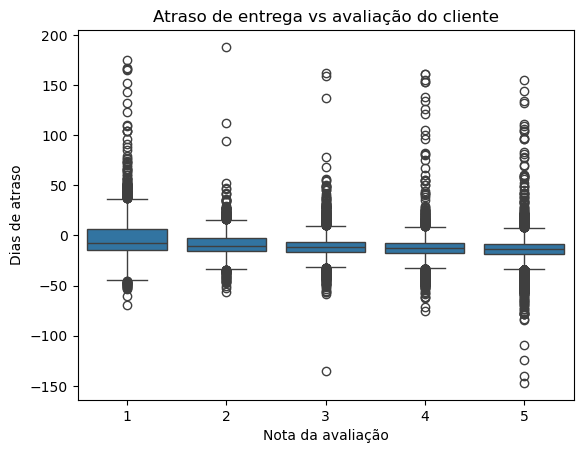

In [54]:
merged = orders.merge(reviews, on='order_id')

sns.boxplot(x='review_score', y='delivery_delay', data=merged)

plt.title('Atraso de entrega vs avaliação do cliente')
plt.xlabel('Nota da avaliação')
plt.ylabel('Dias de atraso')

plt.show()

# Categorias de produtos mais vendidas #

Nesta análise identificamos quais categorias possuem maior volume de vendas.

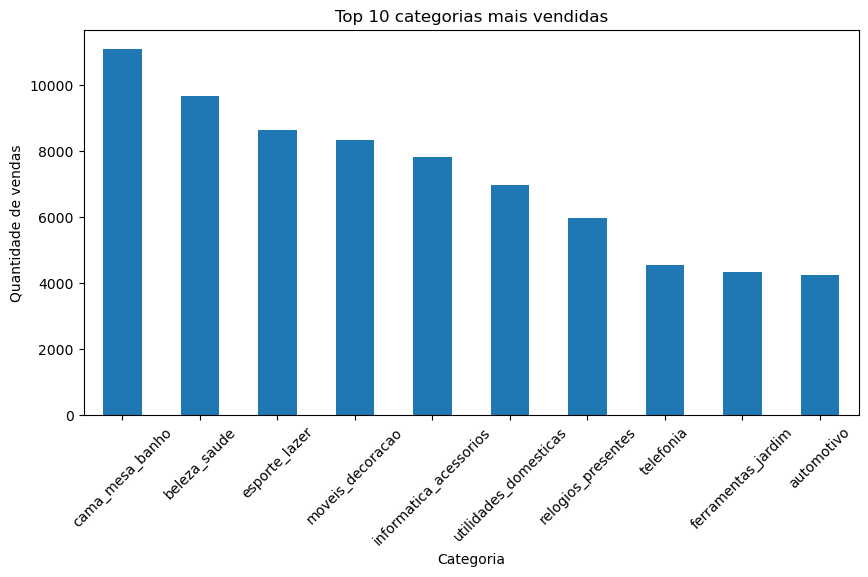

In [55]:
merged_items = items.merge(products, on="product_id")

top_categories = merged_items["product_category_name"].value_counts().head(10)

top_categories.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 categorias mais vendidas")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de vendas")

plt.xticks(rotation=45)

plt.show()

# Distribuição geográfica de clientes #

Esta análise mostra em quais estados estão concentrados os clientes da plataforma.

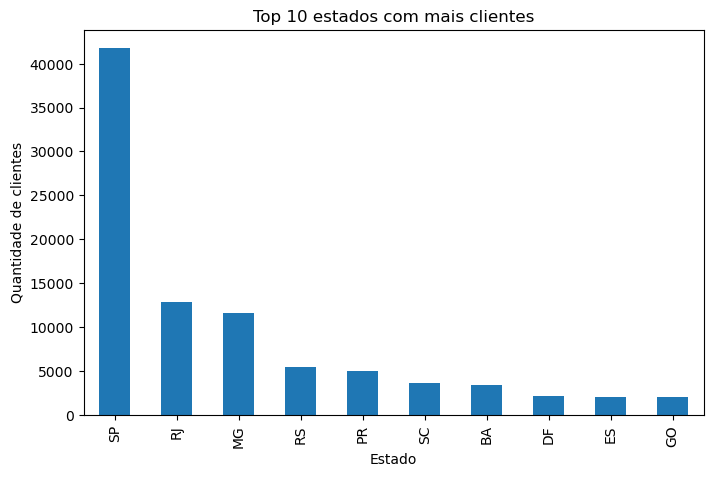

In [56]:
state_counts = customers["customer_state"].value_counts().head(10)

state_counts.plot(kind="bar", figsize=(8,5))

plt.title("Top 10 estados com mais clientes")
plt.xlabel("Estado")
plt.ylabel("Quantidade de clientes")

plt.show()

# Ticket médio dos pedidos #

O ticket médio representa o valor médio gasto por pedido na plataforma.

In [57]:
order_values = payments.groupby("order_id")["payment_value"].sum()

ticket_medio = order_values.mean()

print("Ticket médio dos pedidos: R$", round(ticket_medio, 2))

Ticket médio dos pedidos: R$ 160.99


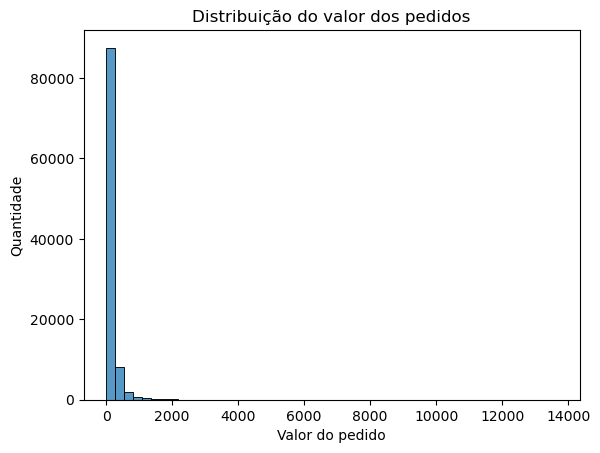

In [58]:
sns.histplot(order_values, bins=50)

plt.title("Distribuição do valor dos pedidos")
plt.xlabel("Valor do pedido")
plt.ylabel("Quantidade")

plt.show()

# Análise de correlação entre variáveis #

Nesta etapa analisamos a correlação entre variáveis numéricas do dataset.

A correlação indica se existe relação entre duas variáveis. Valores próximos de 1 indicam correlação positiva forte, enquanto valores próximos de -1 indicam correlação negativa.

Essa análise ajuda a identificar fatores que podem influenciar o valor das compras e o comportamento do cliente.

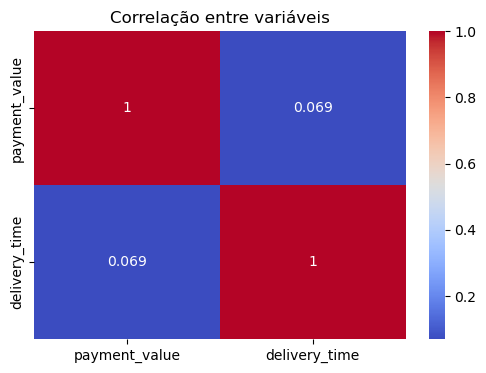

In [59]:
# calcular valor total do pedido
order_values = payments.groupby("order_id")["payment_value"].sum().reset_index()

# juntar com pedidos
df_analysis = orders.merge(order_values, on="order_id")

# converter datas
df_analysis['order_purchase_timestamp'] = pd.to_datetime(df_analysis['order_purchase_timestamp'])
df_analysis['order_delivered_customer_date'] = pd.to_datetime(df_analysis['order_delivered_customer_date'])

# calcular tempo de entrega
df_analysis['delivery_time'] = (
    df_analysis['order_delivered_customer_date'] -
    df_analysis['order_purchase_timestamp']
).dt.days

# selecionar variáveis numéricas
numeric_df = df_analysis[['payment_value','delivery_time']]

# matriz de correlação
corr = numeric_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlação entre variáveis")

plt.show()

# Interpretação da análise #

A matriz de correlação permite observar possíveis relações entre as variáveis analisadas.

No contexto do e-commerce, essa análise pode ajudar a identificar se fatores como tempo de entrega possuem alguma relação com o valor gasto pelos clientes.

Embora a correlação não implique causalidade, ela pode indicar padrões importantes que merecem investigação mais aprofundada.

# Recomendações de Negócio Baseadas nos Dados #

Com base nas análises realizadas, é possível identificar algumas oportunidades estratégicas que poderiam contribuir para a melhoria da experiência do cliente e para o crescimento do negócio.

Uma das principais observações foi a relação entre atrasos nas entregas e avaliações negativas. Isso sugere que melhorias nos processos logísticos podem ter impacto direto na satisfação do cliente. Investimentos em otimização de rotas, escolha de transportadoras mais eficientes e monitoramento mais rigoroso dos prazos de entrega podem ajudar a reduzir atrasos e melhorar a percepção da marca.

A predominância do uso de cartão de crédito como principal método de pagamento indica que esse meio de pagamento deve continuar sendo priorizado em termos de segurança, estabilidade do sistema e experiência de checkout. Ao mesmo tempo, a ampliação de alternativas de pagamento pode ajudar a atingir novos perfis de consumidores.

A identificação das categorias de produtos mais vendidas também abre oportunidades para ações estratégicas de marketing. Campanhas promocionais, destaque dessas categorias na plataforma e estratégias de cross-selling podem aumentar o volume de vendas e elevar o ticket médio dos pedidos.

A análise da distribuição geográfica dos clientes mostrou concentração em determinados estados do país. Essa informação pode orientar decisões relacionadas à expansão logística, abertura de novos centros de distribuição ou campanhas regionais direcionadas.

Por fim, o acompanhamento do ticket médio dos pedidos pode auxiliar na criação de estratégias para aumentar o valor médio das compras, como ofertas combinadas, descontos progressivos ou programas de fidelidade.

Essas recomendações demonstram como a análise de dados pode apoiar a tomada de decisões estratégicas e contribuir para a melhoria contínua do desempenho de plataformas de e-commerce.

# Conclusões e Insights #

A análise exploratória dos dados do dataset de e-commerce da Olist permitiu identificar padrões relevantes sobre o comportamento de compra dos clientes, desempenho logístico e características das transações realizadas na plataforma.

A evolução do volume de pedidos ao longo do tempo indica um crescimento consistente da atividade da plataforma, o que pode estar associado à expansão do comércio eletrônico no Brasil e à consolidação do marketplace no mercado digital.

Em relação aos métodos de pagamento, observou-se uma predominância do uso de cartão de crédito, o que está alinhado com o comportamento típico de consumidores em plataformas de e-commerce. Esse resultado demonstra a importância de manter uma infraestrutura robusta para processamento desse tipo de transação.

A análise das avaliações dos clientes mostrou que a maior parte das avaliações possui notas altas, indicando um nível geral de satisfação positivo com as compras realizadas na plataforma. No entanto, ao cruzar os dados de avaliação com o tempo de entrega, foi possível observar que atrasos nas entregas tendem a estar associados a avaliações mais baixas, sugerindo que a experiência logística exerce impacto direto na percepção do cliente.

A investigação sobre as categorias de produtos revelou que algumas categorias concentram maior volume de vendas, indicando oportunidades estratégicas para ações de marketing e gestão de estoque focadas nos segmentos mais demandados.

Além disso, a distribuição geográfica dos clientes mostrou uma concentração maior em determinados estados brasileiros, o que pode refletir fatores como densidade populacional, acesso à internet e maturidade do mercado de e-commerce nessas regiões.

Por fim, a análise do ticket médio dos pedidos permitiu compreender o valor médio gasto por transação, métrica importante para avaliar o desempenho financeiro da plataforma e apoiar estratégias de aumento de receita.

De forma geral, os resultados da análise demonstram como a exploração de dados pode gerar insights relevantes para apoiar decisões estratégicas relacionadas à logística, experiência do cliente, marketing e crescimento do negócio.